In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings # 실행 중 나오는 경고메시지 정리 

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer # 컬럼종류별로 다른전처리를 적용하는 도구
from sklearn.pipeline import Pipeline # 전처리와 모델학습을 하나의 흐름으로 묶는 도구
from sklearn.preprocessing import OneHotEncoder # 범주형값을 숫자형으로 바꿈
from sklearn.impute import SimpleImputer # 결측치를 정해진규칙으로 채워줌

from xgboost import XGBRegressor # 회귀용 XGBoost

In [ ]:
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

In [3]:
df = pd.read_csv('jeju_bus.csv')
display(df.head()) # print말고 노트북 출력 방식으로 dataframe출력
print('shape:', df.shape)
print('전체 결측치 수:', df.isnull().sum().sum())

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


shape: (210457, 14)
전체 결측치 수: 0


In [4]:
df_model = df.copy()
df_model['original_index'] = df_model.index # 각 행의 원래 번호 저장. 예측결과를 원본행과 연결해서 오차 분석
target_col = 'next_arrive_time'

In [5]:
def prepare_features(df_input, required_cols, target_col):
    data = df_input.copy()
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f'필수 컬럼이 누락되었습니다: {missing_cols}')
    
    data['date'] = pd.to_datetime(data['date']) # 날짜형 변환

    data['day'] = data['date'].dt.day
    data['dayofweek'] = data['date'].dt.dayofweek
    
    data['now_hour'] = (
        data['now_arrive_time'].astype(str).str.extract(r"(\d+)").astype(float) #extract목적이 한그룹만 뽑아서 변환이기때문에 괄호로 묶음
    )

    # data = data.drop(columns=['date', 'now_arrive_time'])
    #if target_col in data.columns:
    #    data = data.drop(columns=[target_col])
    # target_col써야돼서 유지
    # if 'id' in data.columns:
    #    data = data.drop(columns=['id'])
    return data

In [6]:
df_model = prepare_features(df_model, df.columns[1:-1], df.columns[-1])
# 만들어진 시간 feature 분포확인
df_model[['date', 'day', 'dayofweek', 'now_arrive_time', 'now_hour']].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


In [7]:
df_model['station_segment'] = (
    df_model['now_station'].astype(str) + '->' + df_model['next_station'].astype(str)
)

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,original_index,day,dayofweek,now_hour,station_segment
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24,0,15,1,6.0,제주대학교입구->제대마을
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36,1,15,1,6.0,제대마을->제대아파트
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40,2,15,1,6.0,제대아파트->제주대학교
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42,3,15,1,6.0,남국원(아라방면)->제주여자중고등학교(아라방면)
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64,4,15,1,7.0,도호동->은남동


In [8]:
print('station_segment 고유값 개수:', df_model['station_segment'].nunique())
# nunique(): 서로 다른값이 몇종류인지 

station_segment 고유값 개수: 724


In [9]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    """
    위도/경도 사이 거리 km단위 계산
    numpy 기반 Haversine 계산 사용
    컬럼 전체 한번에 계산(벡터)
    """
    earth_radius_km = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [10]:
reference_points = {
    'up':     (33.506286, 126.490312),
    'right':  (33.493521, 126.895326),
    'center': (33.379724, 126.545315),
    'down':   (33.246742, 126.562387)
}

In [11]:
def assign_region_info(data, lat_col, lon_col):
    # 각 기준점 위도, 경도
    up_lat, up_lon = reference_points['up']
    down_lat, down_lon = reference_points['down']
    right_lat, right_lon = reference_points['right']
    center_lat, center_lon = reference_points['center']

    # 각 정류장에서 기준점까지 거리 계산
    distance_to_up = calculate_distance_km(data[lat_col], data[lon_col], up_lat, up_lon)
    distance_to_right = calculate_distance_km(data[lat_col], data[lon_col], down_lat, down_lon)
    distance_to_center = calculate_distance_km(data[lat_col], data[lon_col], right_lat, right_lon)
    distance_to_down = calculate_distance_km(data[lat_col], data[lon_col], center_lat, center_lon)

    # 거리 데이터 프레임 생성. 컬럼명을 저렇게 둬야 idxmin결과가 권역 이름이 됨
    distance_table = pd.DataFrame({
        'up': distance_to_up,
        'down': distance_to_down,
        'right': distance_to_right,
        'center': distance_to_center
    }, index=data.index)

    # 각행에서 가장 가까운 기준점 이름 찾기
    nearest_region = distance_table.idxmin(axis=1)

    # 최종 반환용 데이터 프레임
    result = pd.DataFrame({
        'dist_name': nearest_region,
        'dist_to_up': distance_to_up,
        'dist_to_down': distance_to_down,
        'dist_to_right': distance_to_right,
        'dist_to_center': distance_to_center    
        }, index=data.index)
    return result

In [12]:
# 현재 정류장 기준 권역 정보
now_region_info = assign_region_info(df_model, 'now_latitude', 'now_longitude')
now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,8.532122,23.319056,32.135034
1,up,8.003869,8.710701,23.473015,31.905930
2,up,8.158338,8.861671,23.582519,31.583874
3,up,5.774762,11.118256,25.961685,32.635035
4,up,2.332803,12.673969,27.295447,37.141639


In [13]:
# 다음 정류장 기준 권역 정보
next_region_info = assign_region_info(
    df_model,
    'next_latitude',
    'next_longitude'
)
next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,8.710701,23.473015,31.905930
1,up,8.158338,8.861671,23.582519,31.583874
2,up,8.387595,9.041978,23.701416,31.175511
3,up,5.429627,11.692688,26.539110,32.693959
4,up,2.276139,12.832868,27.400941,37.514443


In [14]:
df_model['now_dist_name'] = now_region_info['dist_name']
df_model['now_dist_to_up'] = now_region_info['dist_to_up']
df_model['now_dist_to_down'] = now_region_info['dist_to_down']
df_model['now_dist_to_right'] = now_region_info['dist_to_right']
df_model['now_dist_to_center'] = now_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,original_index,day,dayofweek,now_hour,station_segment,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,0,15,1,6.0,제주대학교입구->제대마을,up,7.962505,8.532122,23.319056,32.135034
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,1,15,1,6.0,제대마을->제대아파트,up,8.003869,8.710701,23.473015,31.905930
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,2,15,1,6.0,제대아파트->제주대학교,up,8.158338,8.861671,23.582519,31.583874
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,3,15,1,6.0,남국원(아라방면)->제주여자중고등학교(아라방면),up,5.774762,11.118256,25.961685,32.635035
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,4,15,1,7.0,도호동->은남동,up,2.332803,12.673969,27.295447,37.141639


In [15]:
df_model['next_dist_name'] = next_region_info['dist_name']
df_model['next_dist_to_up'] = next_region_info['dist_to_up']
df_model['next_dist_to_down'] = next_region_info['dist_to_down']
df_model['next_dist_to_right'] = next_region_info['dist_to_right']
df_model['next_dist_to_center'] = next_region_info['dist_to_center']

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,...,up,7.962505,8.532122,23.319056,32.135034,up,8.003869,8.710701,23.473015,31.905930
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,...,up,8.003869,8.710701,23.473015,31.905930,up,8.158338,8.861671,23.582519,31.583874
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,...,up,8.158338,8.861671,23.582519,31.583874,up,8.387595,9.041978,23.701416,31.175511
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,...,up,5.774762,11.118256,25.961685,32.635035,up,5.429627,11.692688,26.539110,32.693959
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,...,up,2.332803,12.673969,27.295447,37.141639,up,2.276139,12.832868,27.400941,37.514443


In [16]:
# 현재 정류장 권역과 다음 정류장 권역 조합
df_model['dist_segment_name'] = (
    df_model['now_dist_name'].astype(str) + '->' + df_model['next_dist_name'].astype(str)
)

print('dist_segment_name 고유값 개수:', df_model['dist_segment_name'].nunique())
df_model['dist_segment_name'].value_counts().head()

dist_segment_name 고유값 개수: 12


dist_segment_name
up->up            121131
right->right       48377
center->center     34032
down->down          5512
down->up             321
Name: count, dtype: int64

In [17]:
train_idx, test_idx = train_test_split(df_model.index, test_size=0.2, random_state=42)

In [18]:
len(train_idx), len(test_idx)

(168365, 42092)

In [32]:
def evaluate_regression_model(model_name, experiment, y_true, y_pred, directly_comparable=True, note=""):
    """
    회귀모델 예측결과 평가해서 딕셔너리로 반환
    MAE, RMSE
    directly_comparable : 이모델을 기준 베이스라인 모델과 직접 비교해도 되는지 표시. 평가에 사용한 데이터가 다르면 단순비교 X
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} ')
    # 여러 모델 결과를 표로 모으기 좋게 딕셔너리로 반환
    return {
        'model_name': model_name, 'experiment': experiment, 'directly_comparable': directly_comparable, 'MAE': mae, 'RMSE': rmse, 'note': note
    }

In [33]:
def train_xgb(model_name, experiment, numeric_features, categorical_features, train_idx, test_idx, data_df, directly_comparable=True, note=""):
    """
    XGBoost모델 학습하고 평가하는 함수
    feature목록을 바꿔서 성능 변화 비교
    experiment : feature구성 설명
    """
    # 사용할 feature를 모아서 입력 X와 정답 Y를 만듬
    feats = numeric_features + categorical_features
    X, Y = data_df[feats], data_df[target_col]

    # 같은 행번호로 학습용/검증용 나누기
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    Y_train, Y_test = Y.loc[train_idx], Y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
        remainder='passthrough'
    )

    # 모든 모델이 똑같이 사용하는 XGBoost설정
    # n_estimators: 만들 트리 개수
    # random_state: 결과 재현을 위한 난수 고정값
    # objective   : 회귀로 학습
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, objective='reg:squarederror')
    # 전처리 -> 학습 파이프라인
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, Y_train)
    Y_pred = pipe.predict(X_test)

    evaluation = evaluate_regression_model(model_name, experiment, Y_test, Y_pred, directly_comparable=directly_comparable, note=note)
    # 이후 오차분석 활용하기 위해 파이프라인, 평가결과, 예측값 반환 
    return {'pipeline': pipe, 'evaluation': evaluation, 'y_test': Y_test, 'y_pred': Y_pred}

In [34]:
numeric_features_v2 = ['distance', 'day', 'dayofweek', 'now_hour']
categorical_features_v2 = ['route_nm', 'now_station', 'next_station']

v2_result = train_xgb(
    model_name='v2_original', experiment='EDA 기반 v2 feature',
    numeric_features=numeric_features_v2, categorical_features=categorical_features_v2,
    train_idx=train_idx, test_idx=test_idx, data_df=df_model, note='기준 모델'
)

[v2_original] MAE: 28.7086 | RMSE: 61.6643 


In [35]:
# 검증데이터의 실제값/예측값/오차를 행 단위로 모으기
# 어디서 틀리는지 알기 위해
err = df_model.loc[test_idx].copy()
err['actual'] = v2_result['y_test'].values
err['pred'] = v2_result['y_pred']
err['abs_error'] = np.abs(err['actual'] - err['pred'])

err.sort_values('abs_error', ascending=False)[
    ['actual', 'pred', 'abs_error', 'route_nm', 'now_station', 'next_station', 'now_hour', 'distance']
].head(20)

,actual,pred,abs_error,route_nm,now_station,next_station,now_hour,distance
150855,2906,41.793140,2864.206860,281-1,한국병원,제주버스터미널(가상정류소),8.0,188.0
125929,2888,94.179634,2793.820366,365-21,한라병원,삼무공원사거리,6.0,335.0
201187,2874,80.913696,2793.086304,365-22,제대아파트,제주대학교,18.0,415.0
158593,2882,96.446602,2785.553398,365-22,삼무공원사거리,한라병원,21.0,291.0
87813,2642,50.085686,2591.914314,201-26,서귀포버스터미널(가상정류소),대륜동주민센터,8.0,189.0
112140,2244,64.191193,2179.808807,365-22,노형오거리,남녕고등학교,6.0,252.0
141073,2234,98.249489,2135.750511,360-12,제대아파트,제대마을,15.0,334.0
76849,2160,48.718277,2111.281723,281-2,서귀포버스터미널(가상정류소),대륜동주민센터,18.0,189.0
62004,2160,80.780396,2079.219604,281-2,서귀포여자고등학교,수모루,18.0,746.0
4563,1986,64.191193,1921.808807,365-22,노형오거리,남녕고등학교,8.0,252.0


count    42092.000000
mean        28.708613
std         54.574503
min          0.002121
25%         11.195984
50%         21.588070
75%         34.603176
max       2864.206860
Name: abs_error, dtype: float64

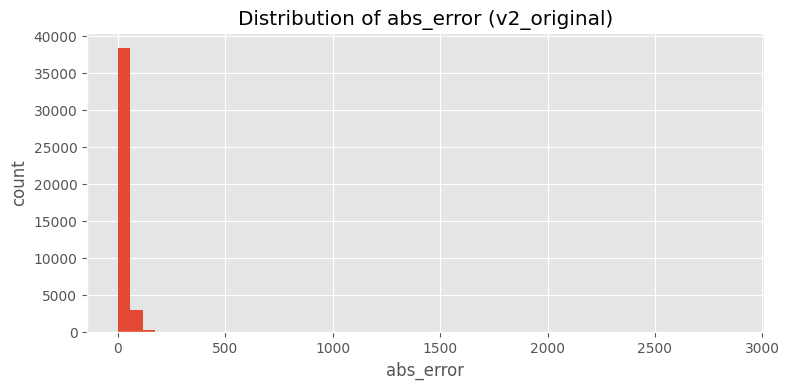

In [36]:
# 오차 분포 확인
display(err['abs_error'].describe())

plt.figure(figsize=(8,4))
plt.hist(err['abs_error'], bins=50) # bins: 값구간을 50개로 나눠서 막대로 표현
plt.title('Distribution of abs_error (v2_original)')
plt.xlabel('abs_error'); plt.ylabel('count')
plt.tight_layout();

In [37]:
# 시간대별 평균오차 확인
hour_error = err.groupby('now_hour')['abs_error'].agg(['count', 'mean']).sort_index()
display(hour_error)

,count,mean
now_hour,,
0.0,2,26.492420
5.0,105,111.828191
6.0,1639,31.797322
7.0,2694,28.042671
8.0,2750,30.937369
9.0,2735,26.424311
10.0,2565,27.586371
11.0,2521,26.255026
12.0,2791,27.675527


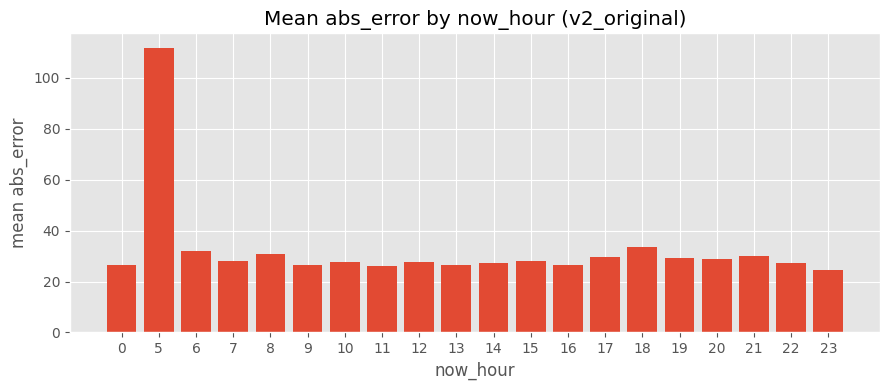

In [38]:
plt.figure(figsize=(9,4))
plt.bar(hour_error.index.astype(int).astype(str), hour_error['mean'])
plt.title('Mean abs_error by now_hour (v2_original)')
plt.xlabel('now_hour'); plt.ylabel('mean abs_error')
plt.tight_layout();
# 5시에 오차가 엄청 큰걸 확인

In [39]:
upper_1pct = df_model[target_col].quantile(0.99)
df_no_outlier = df_model[df_model[target_col] <= upper_1pct].copy()
removed = len(df_model) - len(df_no_outlier)
print(f'상위 1% 경계값: {upper_1pct:.2f} / 제거 {removed}건 ({removed/len(df_model)*100:.2f}%)')

상위 1% 경계값: 340.00 / 제거 2102건 (1.00%)


In [40]:
# 데이터 자체가 달라졌으므로 별도 split 생성
tr_no, te_no = train_test_split(df_no_outlier.index, test_size=0.2, random_state=42)

v2_no_outlier_result = train_xgb(
    model_name='v2_without_top_1pct_target', experiment='v2 feature (동일)',
    numeric_features=numeric_features_v2, categorical_features=categorical_features_v2,
    train_idx=tr_no, test_idx=te_no, data_df=df_no_outlier,
    directly_comparable=False, # 기존모델이랑 직접 비교 불가
    note='평가 대상이 달라 직접 비교 주의'
)

[v2_without_top_1pct_target] MAE: 24.7411 | RMSE: 33.0449 


In [41]:
# station_segment 컬럼 추가
numeric_features_station = ['distance', 'day', 'dayofweek', 'now_hour']
categorical_features_station = ['route_nm', 'now_station', 'next_station', 'station_segment']

v3_result = train_xgb(
    model_name='v3_with_station_segment', experiment='v2 + station_segment',
    numeric_features=numeric_features_station, categorical_features=categorical_features_station,
    train_idx=train_idx, test_idx=test_idx, data_df=df_model,
    note='정류장 구간 feature 추가, feature수 증가'
)

[v3_with_station_segment] MAE: 28.7800 | RMSE: 61.6812 


In [42]:
# 전처리 후 실제 feature 수 비교
try:
    n2 = len(v2_result['pipeline'].named_steps['preprocessor'].get_feature_names_out())
    n3 = len(v3_result['pipeline'].named_steps['preprocessor'].get_feature_names_out())
    print(f'v2_original 전처리 후 feature 수: {n2}')
    print(f'v3_with_station_segment 전처리 후 feature 수: {n3} (증가: {n3-n2})')
except Exception as e:
    print('오류발생 :', e)

v2_original 전처리 후 feature 수: 724
v3_with_station_segment 전처리 후 feature 수: 1444 (증가: 720)


In [43]:
# 권역정보 추가
numeric_features_dist = [
    'distance', 'day', 'dayofweek', 'now_hour', 'now_dist_to_up', 'now_dist_to_down', 'now_dist_to_right', 'now_dist_to_center',
    'next_dist_to_up', 'next_dist_to_down', 'next_dist_to_right', 'next_dist_to_center'
]
categorical_features_dist = ['route_nm', 'now_station', 'next_station', 'dist_segment_name']

v2_dist_result = train_xgb(
    model_name='v2_with_dist_segment_name', experiment='v2 + dist_segment_name',
    numeric_features=numeric_features_dist, categorical_features=categorical_features_dist,
    train_idx=train_idx, test_idx=test_idx, data_df=df_model,
    note='위치 권역 조합 feature 추가'
)

[v2_with_dist_segment_name] MAE: 26.2928 | RMSE: 60.2028 


In [44]:
# 실험결과 딕셔너리를 하나의 표로
comparison_df = pd.DataFrame([
    v2_result['evaluation'],
    v2_no_outlier_result['evaluation'],
    v3_result['evaluation'],
    v2_dist_result['evaluation']
])
comparison_df[['model_name', 'experiment', 'directly_comparable', 'MAE', 'RMSE', 'note']]

,model_name,experiment,directly_comparable,MAE,RMSE,note
0,v2_original,EDA 기반 v2 feature,True,28.708614,61.664331,기준 모델
1,v2_without_top_1pct_target,v2 feature (동일),False,24.741096,33.044902,평가 대상이 달라 직접 비교 주의
2,v3_with_station_segment,v2 + station_segment,True,28.780006,61.681185,"정류장 구간 feature 추가, feature수 증가"
3,v2_with_dist_segment_name,v2 + dist_segment_name,True,26.292803,60.202784,위치 권역 조합 feature 추가


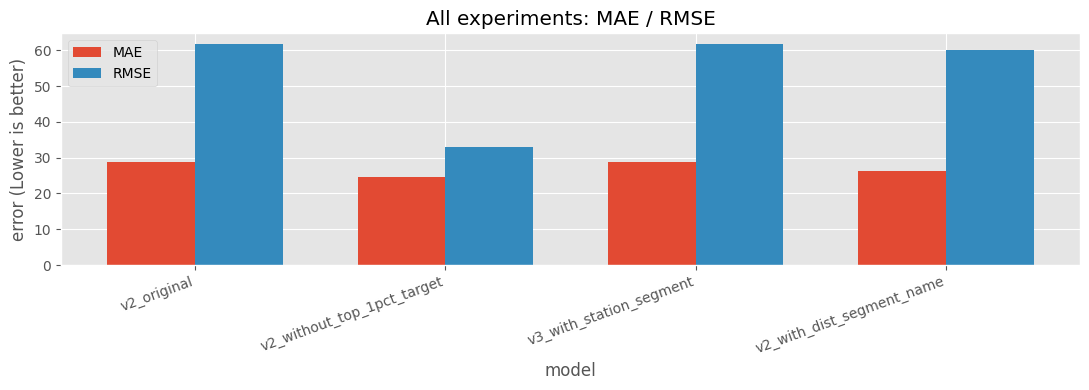

In [46]:
# 표로 결과 확인
names = comparison_df['model_name'].tolist()
x = np.arange(len(names)); width=0.35

plt.figure(figsize=(11, 4))
plt.bar(x - width/2, comparison_df['MAE'], width, label='MAE')
plt.bar(x + width/2, comparison_df['RMSE'], width, label='RMSE')
plt.title('All experiments: MAE / RMSE')
plt.xlabel('model')
plt.ylabel('error (Lower is better)')
plt.xticks(x, names, rotation=20, ha='right');
plt.legend()
plt.tight_layout();

In [47]:
ci = comparison_df.set_index('model_name')
base = ci.loc['v2_original']
targets = comparison_df[(comparison_df['directly_comparable']) &
                        (comparison_df['model_name'] != 'v2_original')]['model_name'].tolist()

rows = [{
    'model_name': name,
    'MAE_diff_vs_v2': ci.loc[name, 'MAE'] - base['MAE'],
    'RMSE_diff_vs_v2': ci.loc[name, 'RMSE'] - base['RMSE']
} for name in targets]
# 데이터 변환 없었던 실험 대상모델만 골라서 표로만듦
pd.DataFrame(rows)

,model_name,MAE_diff_vs_v2,RMSE_diff_vs_v2
0,v3_with_station_segment,0.071392,0.016854
1,v2_with_dist_segment_name,-2.415812,-1.461547


### 정리
- 기준모델은 반드시 필요
- 평균 성능 지표로는 불충분
- feature추가가 항상 성능을 높이지는 않음
- 이상치 제거는 조심
- 같은 조건의 실험 결과만 비교